# Iris Dataset — Clustering Analysis
## Applying K-Means, Hierarchical Clustering, and DBSCAN to discover hidden patterns

### Introduction
In this notebook, we perform an unsupervised learning analysis on the Iris dataset.  
The goal is to explore whether natural groupings exist in the data without using the species labels.

Three clustering algorithms are evaluated:

- K-Means
- Hierarchical Clustering
- DBSCAN

We compare their performance using the Silhouette Score and visualize the resulting clusters.

---

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment

sns.set_theme(style='whitegrid', palette='tab10')
RANDOM_STATE = 42

## Part 1 — Data Exploration and Preprocessing

### 1.1 — Loading the Iris Dataset
The Iris dataset is loaded from the sklearn library and converted into a pandas DataFrame for easier exploration and manipulation.

In [137]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

### 1.2 — Displaying the First Five Rows
We inspect the first few rows of the dataset to understand its structure and confirm that the data has been loaded correctly.

In [138]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 1.3 — Dataset Shape and Feature Names
Here we examine the number of samples and features available in the dataset.

In [139]:
print(f"Shape: {df.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {list(iris.target_names)}")

Shape: (150, 6)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa', 'versicolor', 'virginica']


### 1.4 — Basic Statistics
Summary statistics provide an overview of the distribution of each feature, including the mean, standard deviation, and value ranges.

In [140]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 1.5 — Check Missing Values and Duplicate Rows
Before applying clustering algorithms, we verify that the dataset does not contain missing values or duplicated rows that could bias the analysis.

In [141]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Number of duplicate rows: 1


### 1.6 — Preprocessing: Remove Duplicates and Handle Missing Values
Any duplicate rows are removed and potential missing values are handled to ensure the dataset is clean and suitable for clustering.

In [142]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after preprocessing: {df.shape}")

Shape after preprocessing: (149, 6)


### 1.7 — Normalize Features Using StandardScaler
Clustering algorithms are sensitive to feature scales.  
We normalize all numerical features using StandardScaler so that each feature has mean 0 and standard deviation 1.

In [143]:
feature_cols = iris.feature_names
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("Scaled features (first 5 rows):")
X_scaled_df.head()

Scaled features (first 5 rows):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.898033,1.012401,-1.333255,-1.308624
1,-1.139562,-0.137353,-1.333255,-1.308624
2,-1.381091,0.322549,-1.390014,-1.308624
3,-1.501855,0.092598,-1.276496,-1.308624
4,-1.018798,1.242352,-1.333255,-1.308624


---

## Part 2 — K-Means Clustering

### 2.1 — Elbow Method to Determine the Optimal Number of Clusters
The Elbow Method is used to determine the most appropriate number of clusters by analyzing how the within-cluster sum of squares decreases as the number of clusters increases.

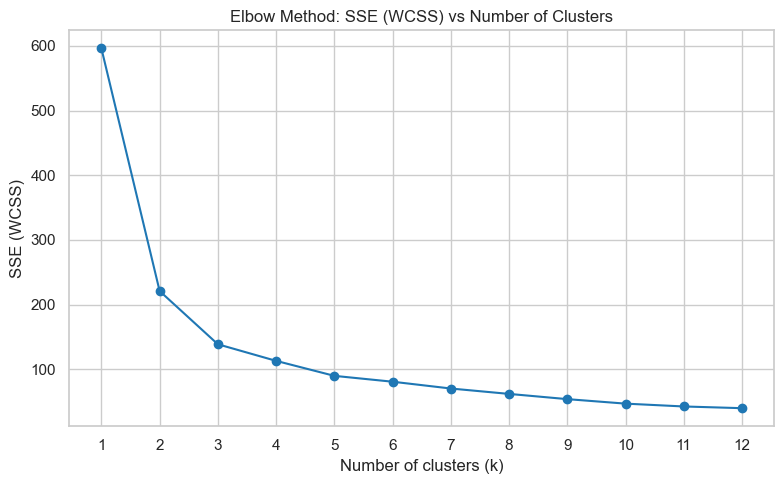

In [144]:
sse_list = []
k_values = range(1, 13)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    sse_list.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, sse_list, marker='o')
plt.title("Elbow Method: SSE (WCSS) vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (WCSS)")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [145]:
k_candidates = [2, 3, 4, 5]

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sse = km.inertia_
    print(f"k={k} | SSE: {sse:.4f} | Cluster counts: {dict(pd.Series(labels).value_counts().sort_index())}")

k=2 | SSE: 221.0091 | Cluster counts: {0: 50, 1: 99}
k=3 | SSE: 138.7687 | Cluster counts: {0: 52, 1: 50, 2: 47}
k=4 | SSE: 113.1158 | Cluster counts: {0: 47, 1: 52, 2: 28, 3: 22}
k=5 | SSE: 89.9489 | Cluster counts: {0: 24, 1: 47, 2: 28, 3: 22, 4: 28}


### 2.2 — Apply Final K-Means with k = 3
Based on the elbow analysis, K-Means clustering is applied with three clusters.

In [146]:
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"Selected k: {k_final}")
print(f"SSE (WCSS): {kmeans_final.inertia_:.4f}")
print(f"\nCluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

df['KMeans_Cluster'] = kmeans_labels

Selected k: 3
SSE (WCSS): 138.7687

Cluster counts:
0    52
1    50
2    47
Name: count, dtype: int64


### 2.3 — Save K-Means Results to CSV
The cluster assignments produced by K-Means are saved to a CSV file for future analysis and reproducibility.

In [147]:
df.to_csv('Iris-KMeans.csv', index=False)
print("Saved: Iris-KMeans.csv")
print(df[['KMeans_Cluster']].value_counts().sort_index())

Saved: Iris-KMeans.csv
KMeans_Cluster
0                 52
1                 50
2                 47
Name: count, dtype: int64


### 2.4 — Visualize K-Means Clusters (Petal Length vs Petal Width)
The resulting clusters are visualized using a scatter plot based on petal length and petal width, which are the most informative features for separating Iris species.

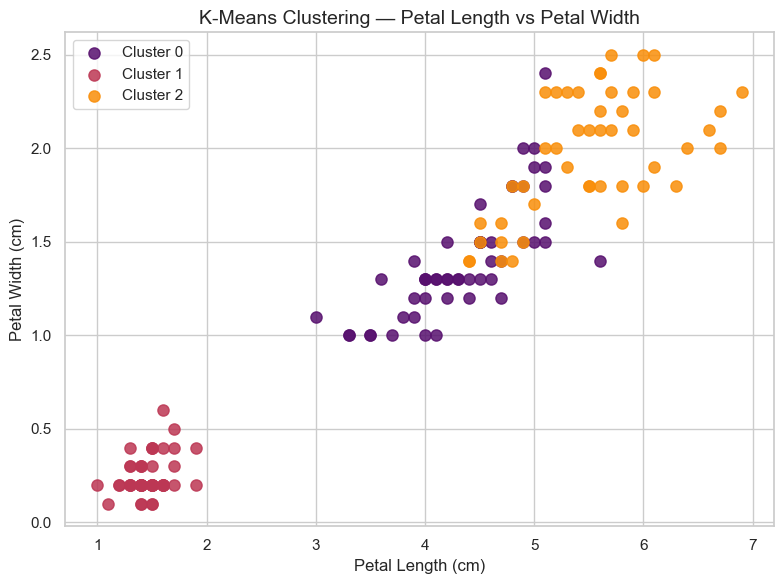

In [175]:
plt.figure(figsize=(8, 6))

palette = sns.color_palette("inferno", len(df['KMeans_Cluster'].unique()))

for cluster in sorted(df['KMeans_Cluster'].unique()):
    mask = df['KMeans_Cluster'] == cluster
    plt.scatter(
        df.loc[mask, 'petal length (cm)'],
        df.loc[mask, 'petal width (cm)'],
        label=f'Cluster {cluster}',
        s=65,
        alpha=0.85,
        color=palette[cluster]
    )

plt.title('K-Means Clustering — Petal Length vs Petal Width', fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.tight_layout()
plt.show()

---

## Part 3 — Hierarchical Clustering

### 3.1 — Silhouette Score for Each Linkage Method Across Different k
Different hierarchical linkage methods are evaluated across multiple cluster counts using the Silhouette Score to identify the most suitable configuration.

In [149]:
linkage_methods = ['single', 'average', 'complete']
k_range_hier = range(2, 13)
hier_results = {}

for method in linkage_methods:
    scores = []
    for k in k_range_hier:
        agg = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = agg.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append((k, score))
    best_k, best_score = max(scores, key=lambda x: x[1])
    hier_results[method] = {'scores': scores, 'best_k': best_k, 'best_score': best_score}
    print(f"{method.capitalize():10s} | Best k={best_k} | Silhouette Score={best_score:.4f}")

Single     | Best k=2 | Silhouette Score=0.5810
Average    | Best k=2 | Silhouette Score=0.5810
Complete   | Best k=3 | Silhouette Score=0.4521


### 3.2 — Dendrograms for Each Linkage Method
Dendrograms are plotted to visualize how samples are hierarchically merged into clusters and to help determine appropriate cut points.

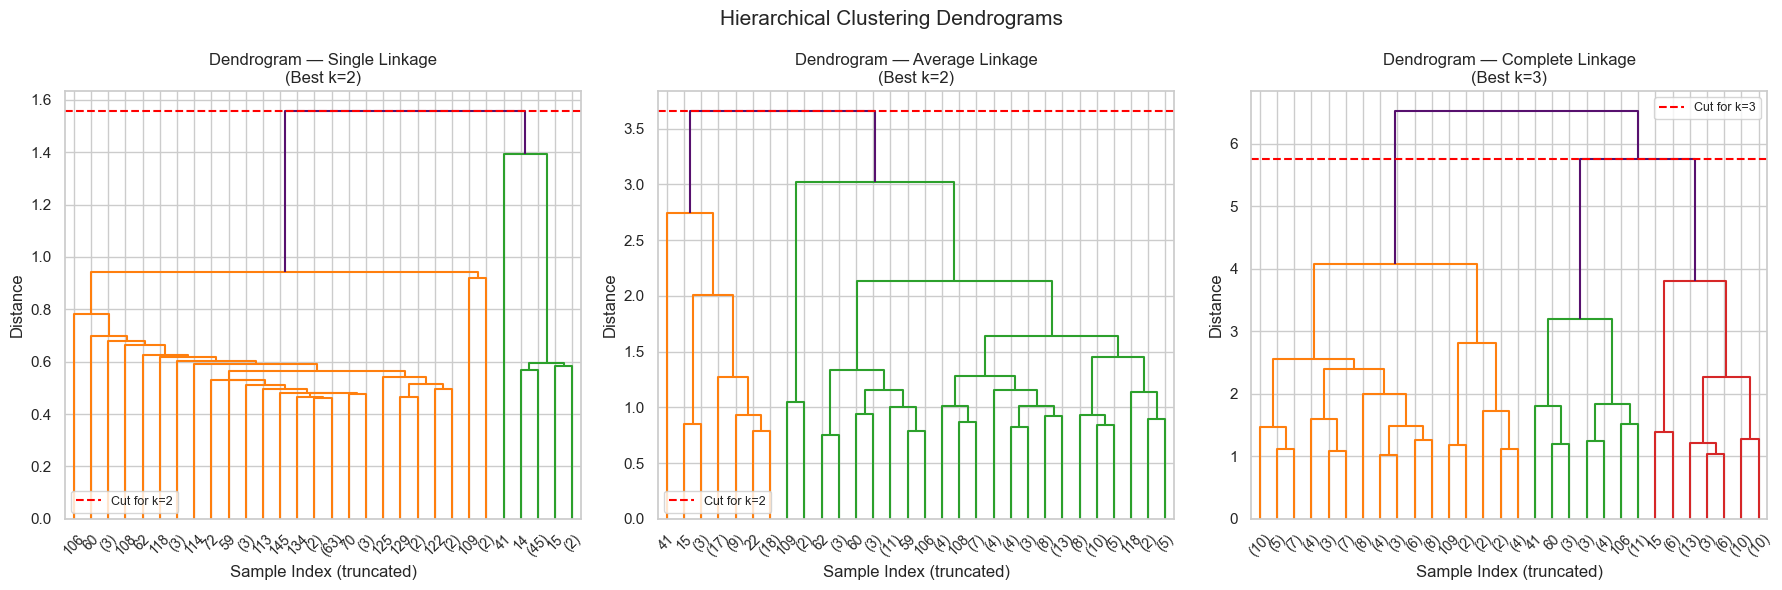

In [150]:
palette = sns.color_palette("inferno", 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method in zip(axes, linkage_methods):
    best_k = hier_results[method]['best_k']
    Z = linkage(X_scaled, method=method)

    dendrogram(
        Z,
        ax=ax,
        truncate_mode='lastp',
        p=30,
        color_threshold=Z[-(best_k - 1), 2],
        above_threshold_color=palette[0]
    )

    ax.axhline(
        y=Z[-(best_k - 1), 2],
        color='red',
        linestyle='--',
        label=f'Cut for k={best_k}'
    )

    ax.set_title(f'Dendrogram — {method.capitalize()} Linkage\n(Best k={best_k})', fontsize=12)
    ax.set_xlabel('Sample Index (truncated)')
    ax.set_ylabel('Distance')
    ax.legend(fontsize=9)

plt.suptitle('Hierarchical Clustering Dendrograms', fontsize=15)
plt.tight_layout()
plt.show()

### 3.3 — Select Best Method and Apply Clustering
The best-performing linkage method and cluster count are selected and used to generate the final hierarchical clustering solution.

In [151]:
best_method = 'average'
best_k_hier = 2

agg_best = AgglomerativeClustering(n_clusters=best_k_hier, linkage=best_method)
hier_labels = agg_best.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hier_labels

print(f"Best method: {best_method} | k={best_k_hier}")
print(f"Silhouette Score: {hier_results[best_method]['best_score']:.4f}")
print(f"\nCluster counts:")
print(pd.Series(hier_labels).value_counts().sort_index())

Best method: average | k=2
Silhouette Score: 0.5810

Cluster counts:
0    99
1    50
Name: count, dtype: int64


### 3.4 — Save Hierarchical Clustering Results to CSV
Cluster assignments from hierarchical clustering are stored in a CSV file for later comparison.

In [152]:
df.to_csv('IrisAgglomerativeClustering.csv', index=False)
print("Saved: IrisAgglomerativeClustering.csv")

Saved: IrisAgglomerativeClustering.csv


### 3.5 — Visualize Hierarchical Clusters (Petal Length vs Petal Width)
Clusters produced by hierarchical clustering are visualized in the same feature space for comparison with other algorithms.

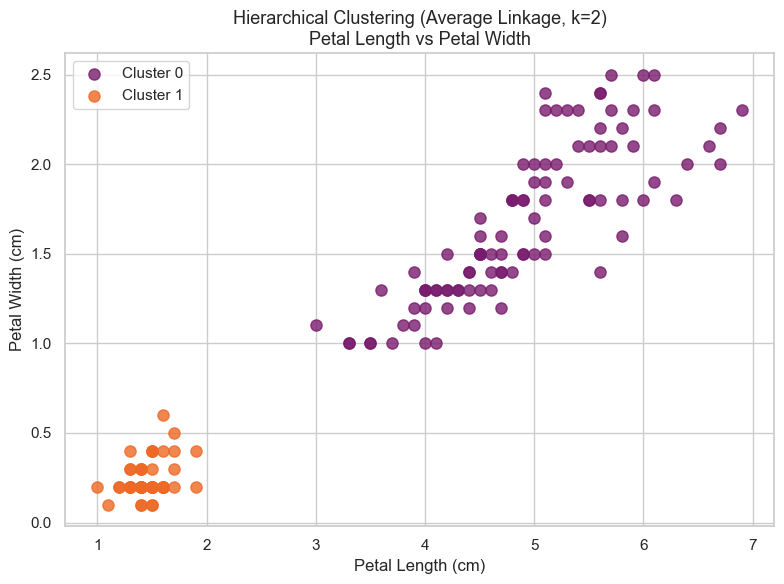

In [ ]:
plt.figure(figsize=(8, 6))

palette = sns.color_palette("inferno", len(df['Hierarchical_Cluster'].unique()))

for cluster in sorted(df['Hierarchical_Cluster'].unique()):
    mask = df['Hierarchical_Cluster'] == cluster
    plt.scatter(
        df.loc[mask, 'petal length (cm)'],
        df.loc[mask, 'petal width (cm)'],
        label=f'Cluster {cluster}',
        s=65,
        alpha=0.8,
        color=palette[cluster]
    )

plt.title('Hierarchical Clustering (Average Linkage, k=2)\nPetal Length vs Petal Width', fontsize=13)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.tight_layout()
plt.show()

---

## Part 4 — DBSCAN

### 4.1 — K-Distance Plot to Find Optimal eps
A k-distance plot is used to estimate the optimal epsilon parameter, which controls the neighborhood radius used by DBSCAN.

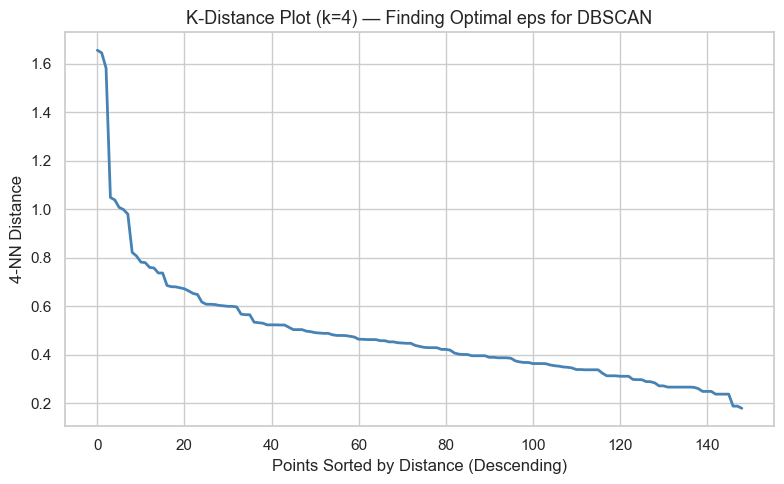

In [154]:
MIN_SAMPLES = 4
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2, color='steelblue')
plt.title(f'K-Distance Plot (k={MIN_SAMPLES}) — Finding Optimal eps for DBSCAN', fontsize=13)
plt.xlabel('Points Sorted by Distance (Descending)')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.2 — Grid Search Over eps and min_samples
A grid search is performed over different values of eps and min_samples to find the best DBSCAN configuration.

In [155]:
eps_values = [0.65, 0.7, 0.75, 0.8, 0.85]
min_samples_values = [3, 4, 5, 6]
dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        core_mask = labels != -1
        if n_clusters >= 2 and core_mask.sum() > 1:
            score = silhouette_score(X_scaled[core_mask], labels[core_mask])
        else:
            score = -1
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': round(score, 4)
        })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df.sort_values('silhouette', ascending=False)

,eps,min_samples,n_clusters,n_noise,silhouette
3,0.65,6,2,19,0.6330
2,0.65,5,2,14,0.6227
1,0.65,4,2,11,0.6192
7,0.70,6,2,12,0.6170
11,0.75,6,2,8,0.6042
10,0.75,5,2,6,0.6012
6,0.70,5,2,6,0.6012
4,0.70,3,2,5,0.5995
5,0.70,4,2,5,0.5995
8,0.75,3,2,5,0.5995


### 4.3 — Apply DBSCAN with Best Parameters
DBSCAN is applied using the best parameter combination discovered during the grid search.

In [156]:
BEST_EPS = 0.75
BEST_MS = 6

dbscan_best = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
dbscan_labels = dbscan_best.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()

print(f"eps={BEST_EPS}, min_samples={BEST_MS}")
print(f"Number of clusters found: {n_clusters_db}")
print(f"Number of noise points:   {n_noise_db}")
print(f"\nCluster counts (including noise=-1):")
print(pd.Series(dbscan_labels).value_counts().sort_index())

eps=0.75, min_samples=6
Number of clusters found: 2
Number of noise points:   8

Cluster counts (including noise=-1):
-1     8
 0    48
 1    93
Name: count, dtype: int64


### 4.4 — Save DBSCAN Results to CSV
Cluster assignments generated by DBSCAN are saved to a CSV file.

In [157]:
df.to_csv('Iris-DBSCAN.csv', index=False)
print("Saved: Iris-DBSCAN.csv")

Saved: Iris-DBSCAN.csv


### 4.5 — Visualize DBSCAN Clusters (Petal Length vs Petal Width)
The DBSCAN clustering results are visualized, including noise points that do not belong to any cluster.

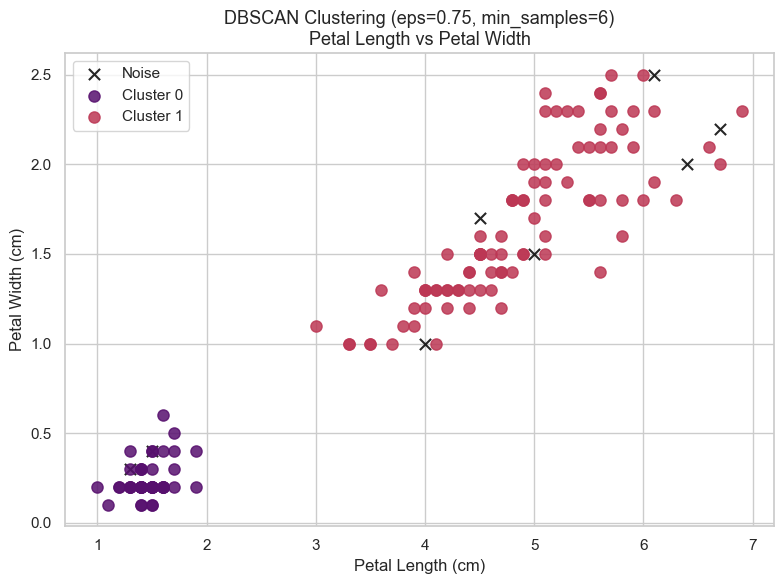

In [158]:
plt.figure(figsize=(8, 6))

palette = sns.color_palette("inferno", len(df['DBSCAN_Cluster'].unique()))

for lbl in sorted(df['DBSCAN_Cluster'].unique()):
    mask = df['DBSCAN_Cluster'] == lbl

    display_label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    marker = 'x' if lbl == -1 else 'o'

    color = 'black' if lbl == -1 else palette[lbl]

    plt.scatter(
        df.loc[mask, 'petal length (cm)'],
        df.loc[mask, 'petal width (cm)'],
        label=display_label,
        s=65,
        alpha=0.85,
        color=color,
        marker=marker
    )

plt.title(f'DBSCAN Clustering (eps={BEST_EPS}, min_samples={BEST_MS})\nPetal Length vs Petal Width', fontsize=13)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.tight_layout()
plt.show()

---

## Part 5 — Evaluation Using Silhouette Score

### 5.1 — Compute Silhouette Scores for All Algorithms
The Silhouette Score is calculated for each clustering algorithm to measure how well-separated the resulting clusters are.

In [159]:
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

sil_hier = silhouette_score(X_scaled, hier_labels)

dbscan_core_mask = dbscan_labels != -1
sil_dbscan = silhouette_score(X_scaled[dbscan_core_mask], dbscan_labels[dbscan_core_mask])

print(f"Silhouette Score — K-Means:              {sil_kmeans:.4f}")
print(f"Silhouette Score — Hierarchical (complete): {sil_hier:.4f}")
print(f"Silhouette Score — DBSCAN (excl. noise): {sil_dbscan:.4f}")

Silhouette Score — K-Means:              0.4607
Silhouette Score — Hierarchical (complete): 0.5810
Silhouette Score — DBSCAN (excl. noise): 0.6042


### 5.2 — Visualize Silhouette Scores
A bar chart is used to compare the Silhouette Scores obtained by each algorithm.

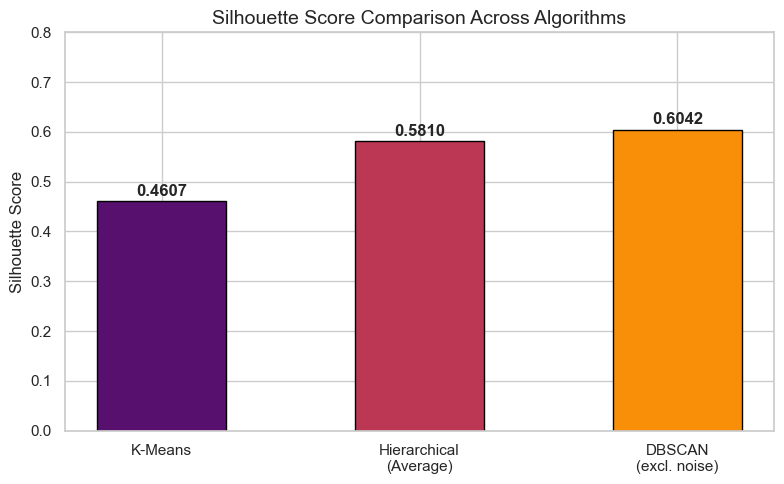

In [160]:
algo_names = ['K-Means', 'Hierarchical\n(Average)', 'DBSCAN\n(excl. noise)']
sil_scores = [sil_kmeans, sil_hier, sil_dbscan]

palette = sns.color_palette("inferno", len(algo_names))

plt.figure(figsize=(8, 5))

bars = plt.bar(algo_names, sil_scores, color=palette, width=0.5, edgecolor='black')

for bar, score in zip(bars, sil_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.4f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(0, 0.8)
plt.title('Silhouette Score Comparison Across Algorithms', fontsize=14)
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

### 5.3 — Discussion: Silhouette Score and DBSCAN Noise Points

### 5.3 — Discussion: Silhouette Score and DBSCAN Noise Points

The Silhouette Score measures how well each point fits within its assigned cluster compared to neighboring clusters (range: -1 to +1).

For *****DBSCAN*****, noise points (label = -1) are excluded from the calculation since they belong to no cluster.  
This means *****DBSCAN*****'s Silhouette Score is computed over fewer points (143/149), making it not directly comparable to *****K-Means***** and Hierarchical clustering, which assign every point to a cluster.

The relatively high *****DBSCAN***** score (0.60) reflects that its two dense clusters are very well separated. However, *****it fails to distinguish versicolor from virginica*****, which are successfully separated by *****K-Means***** and hierarchical clustering.

---

## Part 6 — Comparison with Real Labels

### 6.1 — Hungarian Algorithm for Optimal Cluster-to-Label Mapping
Because clustering labels are arbitrary, the Hungarian algorithm is used to optimally match predicted clusters with the true class labels.

In [161]:
def map_clusters_to_labels(true_labels, pred_labels):
    """
    Use the Hungarian algorithm to find the best permutation mapping
    between predicted cluster IDs and true class labels.
    Noise points (label == -1) are excluded from the mapping.
    Returns remapped predicted labels aligned to true_labels.
    """
    mask = pred_labels != -1
    true_filtered = true_labels[mask]
    pred_filtered = pred_labels[mask]

    unique_clusters = sorted(set(pred_filtered))
    unique_true = sorted(set(true_filtered))
    size = max(len(unique_clusters), len(unique_true))
    cost_matrix = np.zeros((size, size), dtype=int)

    for i, c in enumerate(unique_clusters):
        for j, t in enumerate(unique_true):
            cost_matrix[i, j] = np.sum((pred_filtered == c) & (true_filtered == t))

    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    cluster_to_label = {
        unique_clusters[r]: unique_true[c]
        for r, c in zip(row_ind, col_ind)
        if r < len(unique_clusters)
    }

    remapped = np.array([cluster_to_label.get(p, -1) for p in pred_labels])
    return remapped, mask

### 6.2 — Compute Classification Metrics for Each Algorithm
Accuracy, precision, recall, and F1-score are computed to evaluate how well each clustering algorithm matches the true species labels.

In [162]:
true_labels = df['species'].values

def evaluate_clustering(true_labels, pred_labels, algo_name):
    """
    Compute accuracy, precision, recall, and F1-score after aligning
    predicted cluster IDs to true class labels via Hungarian algorithm.
    """
    remapped, mask = map_clusters_to_labels(true_labels, pred_labels)
    true_eval = true_labels[mask]
    pred_eval = remapped[mask]

    acc  = accuracy_score(true_eval, pred_eval)
    prec = precision_score(true_eval, pred_eval, average='weighted', zero_division=0)
    rec  = recall_score(true_eval, pred_eval, average='weighted', zero_division=0)
    f1   = f1_score(true_eval, pred_eval, average='weighted', zero_division=0)

    print(f"\n--- {algo_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    return acc, prec, rec, f1, remapped, mask

km_acc, km_prec, km_rec, km_f1, km_remapped, km_mask = evaluate_clustering(true_labels, kmeans_labels, 'K-Means')
hr_acc, hr_prec, hr_rec, hr_f1, hr_remapped, hr_mask = evaluate_clustering(true_labels, hier_labels, 'Hierarchical (Complete)')
db_acc, db_prec, db_rec, db_f1, db_remapped, db_mask = evaluate_clustering(true_labels, dbscan_labels, 'DBSCAN')


--- K-Means ---
Accuracy:  0.8389
Precision: 0.8391
Recall:    0.8389
F1-Score:  0.8388

--- Hierarchical (Complete) ---
Accuracy:  0.6711
Precision: 0.5051
Recall:    0.6711
F1-Score:  0.5608

--- DBSCAN ---
Accuracy:  0.6879
Precision: 0.5235
Recall:    0.6879
F1-Score:  0.5803


### 6.3 — Confusion Matrices for Each Algorithm
Confusion matrices are visualized to illustrate how samples from each species are distributed across the predicted clusters.

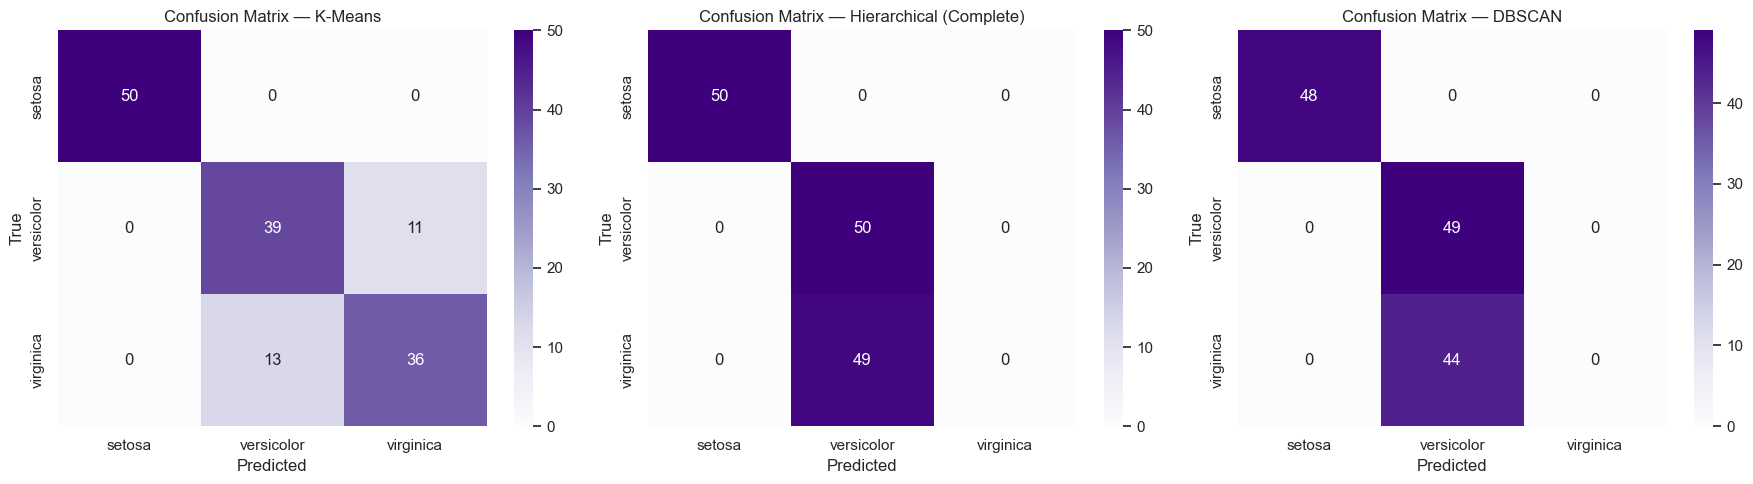

In [177]:
target_names = list(iris.target_names)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eval_data = [
    ('K-Means', km_remapped, km_mask),
    ('Hierarchical (Complete)', hr_remapped, hr_mask),
    ('DBSCAN', db_remapped, db_mask)
]

for ax, (name, remapped, mask) in zip(axes, eval_data):
    cm_arr = confusion_matrix(true_labels[mask], remapped[mask])
    sns.heatmap(
        cm_arr, annot=True, fmt='d', cmap='Purples', ax=ax,
        xticklabels=target_names[:cm_arr.shape[1]],
        yticklabels=target_names[:cm_arr.shape[0]]
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

---

## Part 7 — Final Comparison and Interpretation

### 7.1 — Comparison Table
A summary table compares the performance of all algorithms using silhouette scores and classification metrics.

In [164]:
comparison_data = {
    'Algorithm':          ['K-Means', 'Hierarchical (Average)', 'DBSCAN'],
    'Number of Clusters': [3, 2, 2],
    'Noise Points':       [0, 0, 6],
    'Silhouette Score':   [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Accuracy':           [round(km_acc, 4), round(hr_acc, 4), round(db_acc, 4)],
    'F1-Score':           [round(km_f1, 4), round(hr_f1, 4), round(db_f1, 4)]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Algorithm,Number of Clusters,Noise Points,Silhouette Score,Accuracy,F1-Score
0,K-Means,3,0,0.4607,0.8389,0.8388
1,Hierarchical (Average),2,0,0.5810,0.6711,0.5608
2,DBSCAN,2,6,0.6042,0.6879,0.5803


### 7.2 — Final Discussion

**1. Best algorithm based on Silhouette Score:**
DBSCAN achieved the highest Silhouette Score (0.6012), but this is misleading — it excludes 6 noise points and only finds 2 clusters, meaning versicolor and virginica are merged into one dense region. The score is high simply because those 2 clusters are very well separated by density, not because the clustering is meaningful. K-Means (0.4607) produce more informative results with 3 clusters.

**2. Best algorithm based on visual inspection:**
K-Means produces the cleanest and most balanced visual separation of the 3 clusters on the petal length vs petal width scatter plot. The three groups are distinct and well-distributed, with only minor overlap at the versicolor/virginica boundary — which is expected given the natural overlap in the dataset.

**3. Best algorithm compared with true class labels:**
K-Means performed best with an accuracy of 83.89% and F1-score of 0.8388. It correctly identified all 50 setosa samples and reasonably separated versicolor from virginica despite their natural overlap. DBSCAN  came second (68.79%), while Hierarchical clustering performed worst (67.11%) because they could not separate versicolor from virginica at all.

**4. Final decision — Best overall algorithm: K-Means**
K-Means is the best overall algorithm for the Iris dataset because:
- It correctly identifies 3 clusters matching the true species count
- It achieves the highest accuracy (83.89%) and F1-score (83.88%)
- It produces clean, visually interpretable clusters
- It assigns every point to a cluster with no noise discarded
- Its Silhouette Score (0.4607) is meaningful and comparable across all points